# Machine Learning, Supervised Learning

In [1]:
from google.colab import files
uploaded = files.upload()

Saving train-val.csv to train-val.csv


This project is an exercise on machine learning, it contains data preprocessing, model training, validating and testing. This is specifically for supervised learning for a plethora of models( Naive Bayes, KNeighborsClassifier
, LogisticRegression, MLP with a hidden level, SVC, Decision Tree, Random Forest).

## Preprocessing

In [2]:
import pandas as pd
df = pd.read_csv('train-val.csv')
df.head() #See the data

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2009-03-22,Albury,14.6,30.0,0.0,NaN,NaN,NE,37.0,E,...,56.0,30.0,1014.8,1012.7,3.0,1.0,18.1,29.0,No,No
1,2009-04-15,Albury,10.7,21.9,0.0,NaN,NaN,W,63.0,NW,...,44.0,27.0,1008.2,1009.8,2.0,NaN,20.5,18.9,No,No
2,2009-04-21,Albury,5.7,21.4,0.0,NaN,NaN,ESE,17.0,ENE,...,68.0,39.0,1025.2,1020.9,NaN,NaN,12.2,20.9,No,No
3,2009-04-24,Albury,10.6,16.2,0.0,NaN,NaN,WNW,39.0,ESE,...,74.0,86.0,1008.9,1002.4,8.0,8.0,14.9,15.1,No,Yes
4,2009-05-19,Albury,3.7,19.1,0.0,NaN,NaN,SSE,19.0,NaN,...,87.0,51.0,1023.6,1019.9,NaN,NaN,7.4,18.9,No,No


In [3]:
# we recognize RainTomorrow as the label
#drop the unlabelled rows
df.dropna(subset=['RainTomorrow'], inplace=True)

In [4]:
X = df.iloc[:, :-1]  # split parameters from label
y = df.iloc[:, -1]

In [5]:
feature_names = X.columns
label_name = y.name

print("Feature names:", feature_names)
print("Label column:", label_name)

Feature names: Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday'],
      dtype='object')
Label column: RainTomorrow


In [6]:
# Important info extraction with info
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9800 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9800 non-null   object 
 1   Location       9800 non-null   object 
 2   MinTemp        9750 non-null   float64
 3   MaxTemp        9780 non-null   float64
 4   Rainfall       9699 non-null   float64
 5   Evaporation    5577 non-null   float64
 6   Sunshine       5094 non-null   float64
 7   WindGustDir    9097 non-null   object 
 8   WindGustSpeed  9101 non-null   float64
 9   WindDir9am     9037 non-null   object 
 10  WindDir3pm     9505 non-null   object 
 11  WindSpeed9am   9702 non-null   float64
 12  WindSpeed3pm   9606 non-null   float64
 13  Humidity9am    9668 non-null   float64
 14  Humidity3pm    9543 non-null   float64
 15  Pressure9am    8834 non-null   float64
 16  Pressure3pm    8830 non-null   float64
 17  Cloud9am       6087 non-null   float64
 18  Cloud3pm     

In [7]:
y.info()

<class 'pandas.core.series.Series'>
Index: 9800 entries, 0 to 9999
Series name: RainTomorrow
Non-Null Count  Dtype 
--------------  ----- 
9800 non-null   object
dtypes: object(1)
memory usage: 153.1+ KB


We can now easily see that our data table has 9800 columns, and therefore 9800 samples (after removing the rows that have no value in the label). Most of the data are numerical, but there are also some that are words, such as location, date, wind direction, and of course whether it rained today or tomorrow.

In [8]:
X.describe(include='object')

,Date,Location,WindGustDir,WindDir9am,WindDir3pm,RainToday
count,9800,9800,9097,9037,9505,9699
unique,2372,49,16,16,16,2
top,2011-09-18,Canberra,N,N,W,No
freq,13,247,728,839,711,7525


In [9]:
y.describe(include='object')

,RainTomorrow
count,9800
unique,2
top,No
freq,7483


In [10]:
# Numerical Parameters
numerical_X = X.select_dtypes(include='number')

# Correlation Matrix
corr = numerical_X.corr()
corr

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
MinTemp,1.000000,0.709686,0.095807,0.458621,0.042625,0.150282,0.176686,0.175913,-0.227348,0.026871,-0.360109,-0.373036,0.080924,0.022767,0.888211,0.677807
MaxTemp,0.709686,1.000000,-0.101811,0.578265,0.462325,0.001712,-0.009162,0.050194,-0.489259,-0.505448,-0.214618,-0.318230,-0.293437,-0.286147,0.880796,0.985864
Rainfall,0.095807,-0.101811,1.000000,-0.077591,-0.234593,0.169568,0.112178,0.078621,0.216736,0.254096,-0.177475,-0.119537,0.204007,0.167176,-0.001551,-0.105943
Evaporation,0.458621,0.578265,-0.077591,1.000000,0.338988,0.171932,0.196610,0.152926,-0.507476,-0.373646,-0.202853,-0.234870,-0.167397,-0.151476,0.551054,0.556832
Sunshine,0.042625,0.462325,-0.234593,0.338988,1.000000,-0.092772,-0.027570,0.031783,-0.457613,-0.624284,0.118861,0.053554,-0.690191,-0.707985,0.276213,0.483317
WindGustSpeed,0.150282,0.001712,0.169568,0.171932,-0.092772,1.000000,0.623238,0.704108,-0.203792,0.015896,-0.471944,-0.423275,0.087086,0.128852,0.117589,-0.033887
WindSpeed9am,0.176686,-0.009162,0.112178,0.196610,-0.027570,0.623238,1.000000,0.537449,-0.274388,-0.006767,-0.253680,-0.203172,0.042629,0.080827,0.132999,-0.021373
WindSpeed3pm,0.175913,0.050194,0.078621,0.152926,0.031783,0.704108,0.537449,1.000000,-0.154811,0.006770,-0.314178,-0.275483,0.053168,0.037470,0.166699,0.025836
Humidity9am,-0.227348,-0.489259,0.216736,-0.507476,-0.457613,-0.203792,-0.274388,-0.154811,1.000000,0.645140,0.112275,0.161359,0.440619,0.343380,-0.477720,-0.481655
Humidity3pm,0.026871,-0.505448,0.254096,-0.373646,-0.624284,0.015896,-0.006767,0.006770,0.645140,1.000000,-0.073042,0.006369,0.513814,0.521974,-0.218831,-0.554057


We will use a heatmap to better display the correlations.

<Axes: >

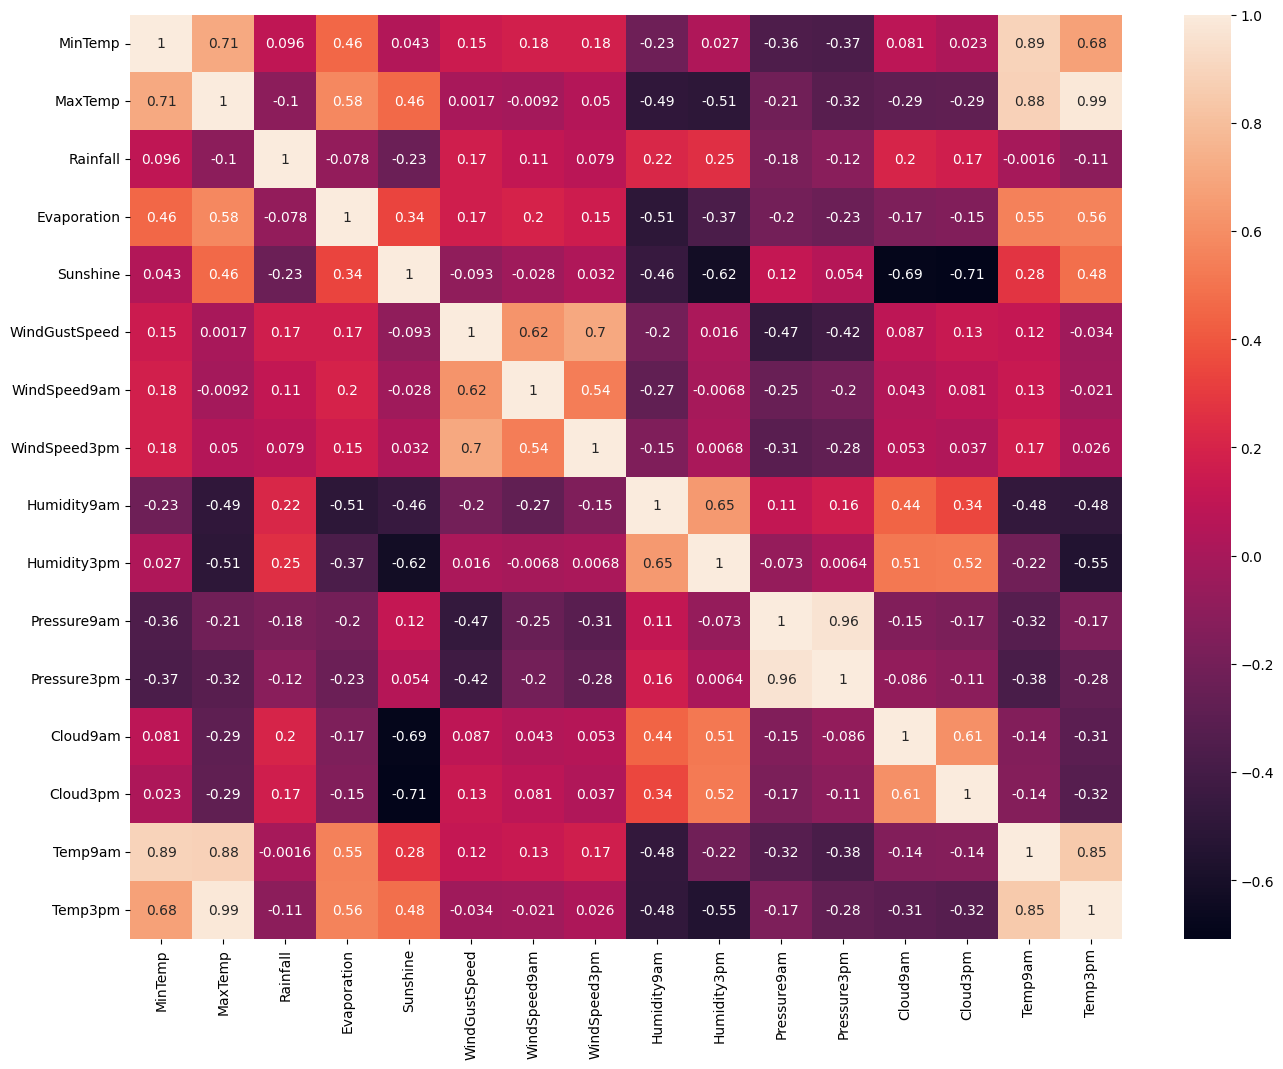

In [11]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(16, 12))
sns.heatmap(corr, annot = True)

Και τώρα όλα είναι καθαρά.

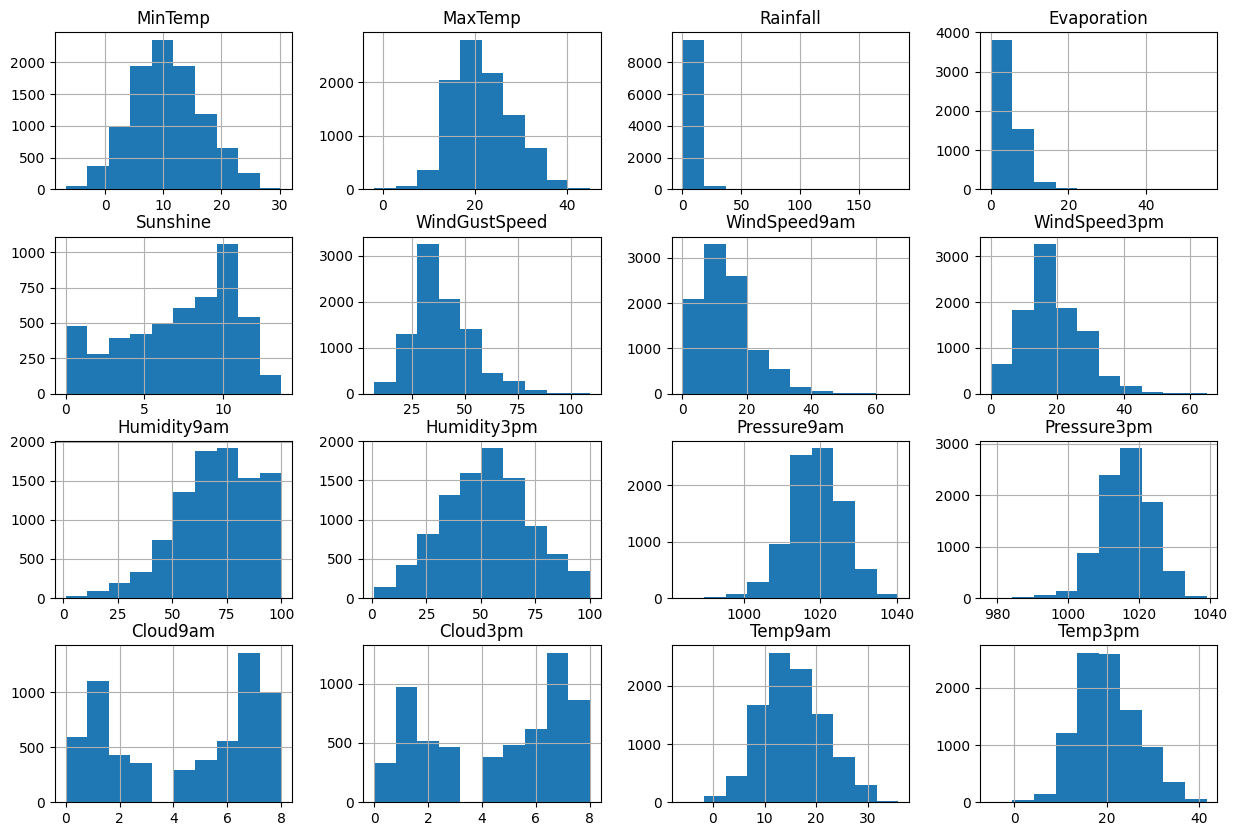

In [12]:
#let's also do some histograms for understanding the data distribution a little better.
import matplotlib.pyplot as plt
X.hist(bins=10, figsize=(15, 10))
plt.show()

I will remove the 9AM temperature, since it is highly correlated with the minimum temperature of the day. Similarly, the 3PM temperature is practically identical to the daily maximum, so I can keep only the minimum and maximum temperature values instead of these hourly measurements.

In addition, cloudiness and sunshine are by definition opposite quantities: when there is sunshine there are no clouds, and when there are clouds there is no sunshine. Therefore, I will exclude the Sunshine variable due to its strong correlation (~70%) with the two cloud measurements. For the same reason, I will also remove WindGustSpeed.

Furthermore, I will keep only one of the two pressure measurements; I choose the 9AM value because it is the older one, and the two pressures have a 95% correlation.

Finally, the Rainfall column fully determines the RainToday column: if it has not rained up to a given maximum, Rainfall is zero; if it has rained, Rainfall shows how much. The only potential issue would be cases where it rained but Rainfall was not recorded.

I verify all these assumptions with code.

In [13]:
# Zero Rainfall but RainToday='Yes'
non_zero_rainfall_and_no_raintoday = df[(df['Rainfall'] > 0) & (df['RainToday'] == 'No')]
print(f"# of rows with zero Rainfall and RainToday='No': {len(non_zero_rainfall_and_no_raintoday)}")

# Zero Rainfall but RainToday=No
raintoday_yes_and_zero_rainfall = df[(df['RainToday'] == 'Yes') & (df['Rainfall'] == 0)]
print(f"# of rows with zero Rainfall and RainToday='Yes': {len(raintoday_yes_and_zero_rainfall)}")

# of rows with zero Rainfall and RainToday='No': 1408
# of rows with zero Rainfall and RainToday='Yes': 0


In [14]:
# Finding maximum Rainfall of rows with RainToday='No'
max_rainfall_raintoday_no = df[df['RainToday'] == 'No']['Rainfall'].max()
print(f"Maximum Rainfall with RainToday='No': {max_rainfall_raintoday_no}")

# Finding minimum Rainfall of rows with RainToday='Yes'
min_rainfall_raintoday_yes = df[df['RainToday'] == 'Yes']['Rainfall'].min()
print(f"Minimum Rainfall with RainToday='Yes': {min_rainfall_raintoday_yes}")

Maximum Rainfall with RainToday='No': 1.0
Minimum Rainfall with RainToday='Yes': 1.2


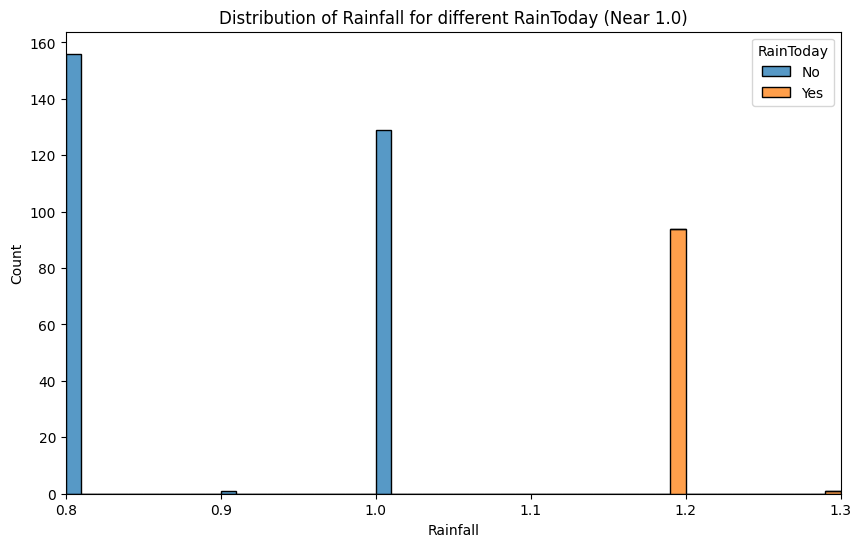

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram of 'Rainfall' for RainToday='Yes' and RainToday='No'
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Rainfall', hue='RainToday', multiple='stack', bins=50, binrange=(0.8, 1.3)) # Close to 1.0
plt.xlim(0.8, 1.3)
plt.title('Distribution of Rainfall for different RainToday (Near 1.0)')
plt.xlabel('Rainfall')
plt.ylabel('Count')
plt.show()

In [16]:
# Check if rows with rainfall= 1.1 exist.
rainfall_1_1_samples = df[df['Rainfall'] == 1.1]

if not rainfall_1_1_samples.empty:
    print("there are rows with Rainfall 1.1:")
    display(rainfall_1_1_samples)
else:
    print("There are no rows with Rainfall 1.1.")

There are no rows with Rainfall 1.1.


It is now clear that raintoday is contained in rainfall. When rainfall>1.1  this is recorded as raintoday=yes, it is clear that all information is contained in rainfall.

In [17]:
# Mean MaxTemp and MinTemp in a new row
df['MeanTemp'] = df[['MaxTemp', 'MinTemp']].mean(axis=1)

# Correlation Matrix
temp_corr = df[['MaxTemp', 'MinTemp', 'Temp9am', 'Temp3pm', 'MeanTemp']].corr()


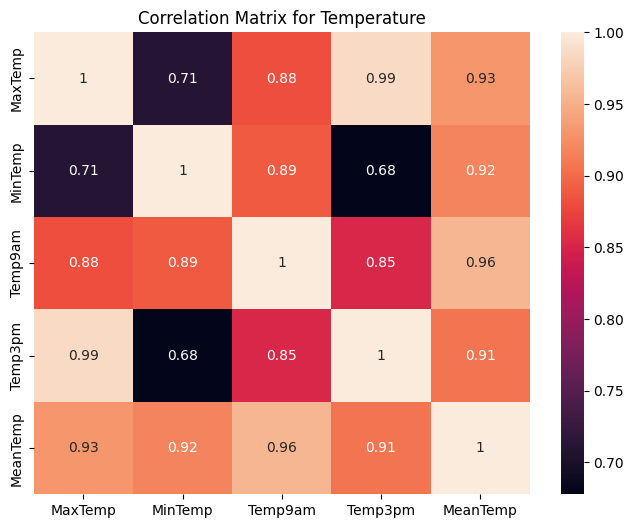

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(temp_corr, annot=True)
plt.title('Correlation Matrix for Temperature')
plt.show()

In [19]:
#The same for wind speed:
# Mean
df['MeanWind'] = df[['WindSpeed9am', 'WindSpeed3pm']].mean(axis=1)

# Correlation Matrix
wind_corr = df[['WindSpeed9am', 'WindSpeed3pm', 'WindGustSpeed', 'MeanWind']].corr()

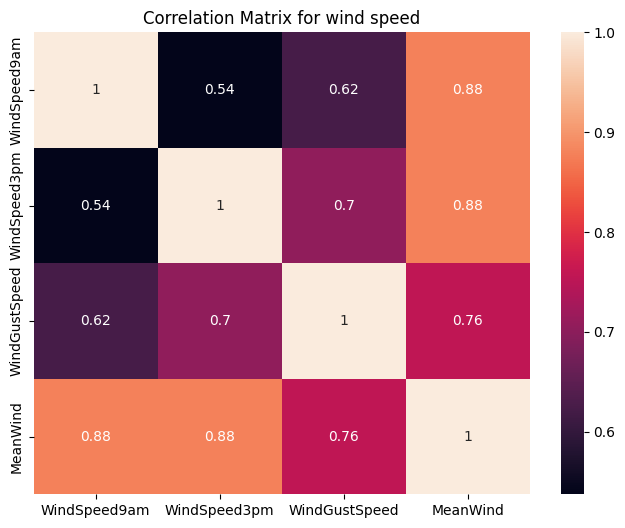

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(wind_corr, annot=True)
plt.title('Correlation Matrix for wind speed')
plt.show()

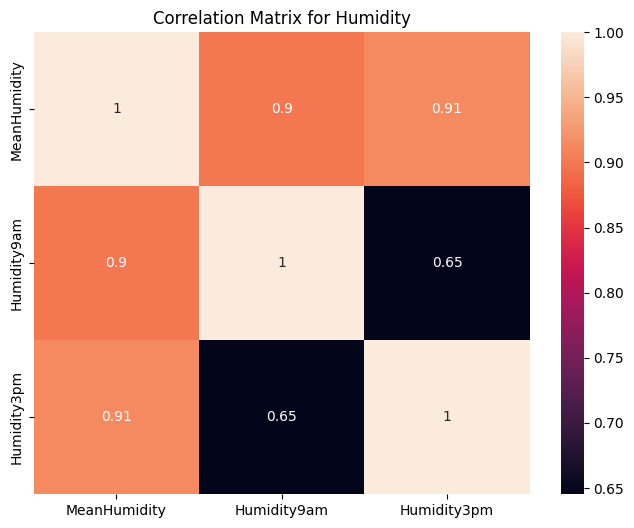

In [21]:
# Mean Humidity
df['MeanHumidity'] = df[['Humidity9am', 'Humidity3pm']].mean(axis=1)

# Correlation Matrix
Humidity_corr = df[['MeanHumidity','Humidity9am', 'Humidity3pm']].corr()

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(Humidity_corr, annot=True)
plt.title('Correlation Matrix for Humidity')
plt.show()

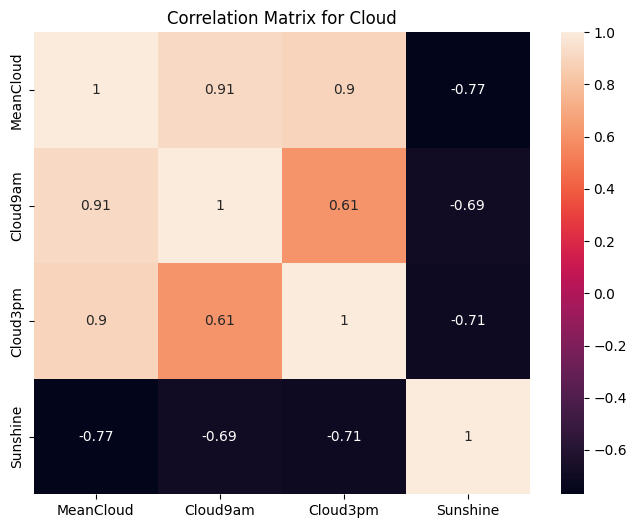

In [22]:
#Mean cloud
df['MeanCloud'] = df[['Cloud9am', 'Cloud3pm']].mean(axis=1)

# Correlation Matrix
Cloud_corr = df[['MeanCloud','Cloud9am', 'Cloud3pm','Sunshine']].corr()

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(Cloud_corr, annot=True)
plt.title('Correlation Matrix for Cloud')
plt.show()

I see that the mean values have very strong linear correlations with all the temperature, wind, cloud, and humidity features respectively, so I will replace all of them with their corresponding means. I also remove Sunshine, since it has a strong correlation with average cloudiness.

In [23]:
#Replacing Temps, Windspeeds, Humidities & Clouds  with their mean.
X = X.drop(['Temp9am','Temp3pm','MaxTemp','MinTemp','Cloud9am', 'Cloud3pm','Humidity9am', 'Humidity3pm','Sunshine','WindGustSpeed','WindSpeed9am','WindSpeed3pm','Sunshine','Pressure9am','RainToday'], axis=1)

X['MeanTemp'] = df['MeanTemp']
X['MeanWind'] = df['MeanWind']
X['MeanHumidity'] = df['MeanHumidity']
X['MeanCloud'] = df['MeanCloud']

In [24]:
#missing values
X.isnull().sum()

,0
Date,0
Location,0
Rainfall,101
Evaporation,4223
WindGustDir,703
WindDir9am,763
WindDir3pm,295
Pressure3pm,970
MeanTemp,8
MeanWind,64


Before performing a general imputation, I would like to handle the Evaporation and Location columns more carefully, since both of them will cause problems. The Location variable, once one‑hot encoded, will create 48 additional columns, and Evaporation would introduce bias if I simply imputed it with the mean due to the large amount of missing data.

The idea is the following: compute mean evaporation values grouped by location and create a new feature based on these group means. Under different circumstances I would remove the column entirely, but evaporation is an important parameter for predicting rainfall. At the same time, instead of filling 5000 missing values with a single global mean, grouping by location provides a more meaningful imputation strategy.

In [25]:
df['Evaporation'] = df.groupby('Location')['Evaporation'].transform(lambda x: x.fillna(x.mean()))

# Are there still missing values?
print("Gaps in Evaporation after imputing with mean of each location:")
print(df['Evaporation'].isnull().sum())

X['Evaporation']=df['Evaporation']

# Drop Location
X = X.drop('Location', axis=1)


Gaps in Evaporation after imputing with mean of each location:
3097


There are locations that have no evaporation values at all—most likely because they do not have a sensor. Nevertheless, we have significantly reduced the number of missing entries. Although I still have some reservations, I will keep the feature and proceed with standard imputation using KNN. This is especially important for Evaporation and Mean Cloud, which contain the most missing values, but I will apply KNN imputation more generally as well for convenience.

In [26]:
# Just to see
# Numerical
numerical_features = X.select_dtypes(include=['number']).columns.tolist()

# Categorical
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print("Numerical:", numerical_features)
print("Categorical:", categorical_features)

Numerical: ['Rainfall', 'Evaporation', 'Pressure3pm', 'MeanTemp', 'MeanWind', 'MeanHumidity', 'MeanCloud']
Categorical: ['Date', 'WindGustDir', 'WindDir9am', 'WindDir3pm']


In [27]:
from sklearn.impute import KNNImputer
import numpy as np
import pandas as pd

# Find numerical features with gaps
numerical_features_with_nan = X.select_dtypes(include=np.number).columns[X.select_dtypes(include=np.number).isnull().any()].tolist()

# KNN imputer
knn_imputer = KNNImputer(n_neighbors=5)

# Apply it
X[numerical_features_with_nan] = knn_imputer.fit_transform(X[numerical_features_with_nan])

print("Missing values after KNN impute:")
print(X.isnull().sum())

Missing values after KNN impute:
Date              0
Rainfall          0
Evaporation       0
WindGustDir     703
WindDir9am      763
WindDir3pm      295
Pressure3pm       0
MeanTemp          0
MeanWind          0
MeanHumidity      0
MeanCloud         0
dtype: int64


In [28]:
from sklearn.impute import SimpleImputer

# Most frequent imputing for categorical
categorical_imputer = SimpleImputer(strategy='most_frequent')
X[categorical_features] = categorical_imputer.fit_transform(X[categorical_features])

print("Missing values after impute")
print(X.isnull().sum())

Missing values after impute
Date            0
Rainfall        0
Evaporation     0
WindGustDir     0
WindDir9am      0
WindDir3pm      0
Pressure3pm     0
MeanTemp        0
MeanWind        0
MeanHumidity    0
MeanCloud       0
dtype: int64


In [29]:
import numpy as np
import pandas as pd
# I will convert all wind direction categories into angular values in degrees, using North as 0°.
direction_map = {
    'N': 0, 'NNE': 22.5, 'NE': 45, 'ENE': 67.5, 'E': 90, 'ESE': 112.5,
    'SE': 135, 'SSE': 157.5, 'S': 180, 'SSW': 202.5, 'SW': 225, 'WSW': 247.5,
    'W': 270, 'WNW': 292.5, 'NW': 315, 'NNW': 337.5
}
#I can create a daily wind direction
wind_direction_cols = ['WindGustDir', 'WindDir9am', 'WindDir3pm']

for col in wind_direction_cols:
    original_wind_data = df[col]
    degrees = original_wind_data.map(direction_map)
    X[col] = degrees

# Mean of the two different time stamps
X['MeanWindDir'] = X[['WindDir9am', 'WindDir3pm']].mean(axis=1)

# Round up to the nearest direction.
valid_angles = np.array(list(direction_map.values()))
X['MeanWindDir'] = X['MeanWindDir'].apply(lambda x: valid_angles[np.argmin(np.abs(valid_angles - x))] if pd.notna(x) else x)
print(X.isnull().sum())
display(X.head())

Date              0
Rainfall          0
Evaporation       0
WindGustDir     703
WindDir9am      763
WindDir3pm      295
Pressure3pm       0
MeanTemp          0
MeanWind          0
MeanHumidity      0
MeanCloud         0
MeanWindDir     131
dtype: int64


,Date,Rainfall,Evaporation,WindGustDir,WindDir9am,WindDir3pm,Pressure3pm,MeanTemp,MeanWind,MeanHumidity,MeanCloud,MeanWindDir
0,2009-03-22,0.0,5.493543,45.0,90.0,22.5,1012.7,22.30,11.5,43.0,2.0,45.0
1,2009-04-15,0.0,4.136190,270.0,315.0,270.0,1009.8,16.30,28.5,35.5,2.0,292.5
2,2009-04-21,0.0,3.206714,112.5,67.5,157.5,1020.9,13.55,6.5,53.5,1.3,112.5
3,2009-04-24,0.0,1.946667,292.5,112.5,22.5,1002.4,13.40,5.5,80.0,8.0,67.5
4,2009-05-19,0.0,2.588772,157.5,NaN,157.5,1019.9,11.40,5.5,69.0,4.0,157.5


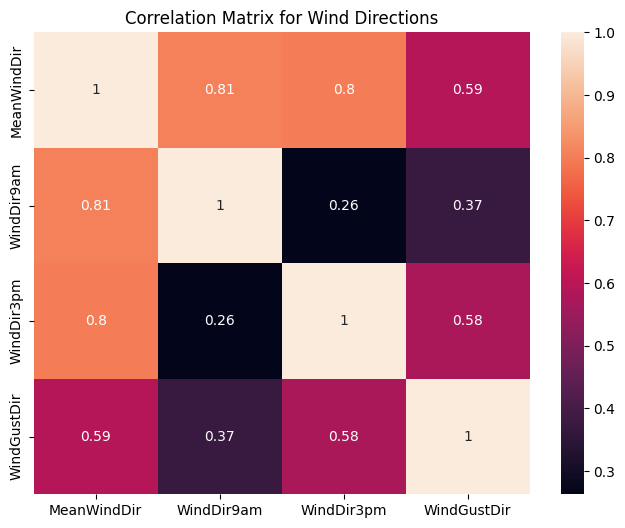

In [30]:
# Correlation Matrix
wind_corr_data = X[['MeanWindDir', 'WindDir9am', 'WindDir3pm', 'WindGustDir']]

WindDir_corr = wind_corr_data.corr()

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(WindDir_corr, annot=True)
plt.title('Correlation Matrix for Wind Directions')
plt.show()

We see that our new numerical variable for mean wind direction can replace the two directional variables at 9AM and 3PM, since it shows strong correlation with both.

In [31]:
import datetime
#I will change the format of the Date column so that I can examine it in more detail and convert it into numerical values.
X['Date'] = pd.to_datetime(X['Date'])
X['Year'] = X['Date'].dt.year
X['Month'] = X['Date'].dt.month
#day may confuse the model
#X['Day'] = X['Date'].dt.day
#droping date after split
X = X.drop(columns=['Date'])
X.info()
print(X.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 9800 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rainfall      9800 non-null   float64
 1   Evaporation   9800 non-null   float64
 2   WindGustDir   9097 non-null   float64
 3   WindDir9am    9037 non-null   float64
 4   WindDir3pm    9505 non-null   float64
 5   Pressure3pm   9800 non-null   float64
 6   MeanTemp      9800 non-null   float64
 7   MeanWind      9800 non-null   float64
 8   MeanHumidity  9800 non-null   float64
 9   MeanCloud     9800 non-null   float64
 10  MeanWindDir   9669 non-null   float64
 11  Year          9800 non-null   int32  
 12  Month         9800 non-null   int32  
dtypes: float64(11), int32(2)
memory usage: 995.3 KB
Rainfall          0
Evaporation       0
WindGustDir     703
WindDir9am      763
WindDir3pm      295
Pressure3pm       0
MeanTemp          0
MeanWind          0
MeanHumidity      0
MeanCloud         0


In [32]:
X = X.drop(['WindDir9am','WindDir3pm'], axis=1)

In [33]:
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd

# I set numerical and categorical again
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()

print("Missing values")
print(X.isnull().sum())

Missing values
Rainfall          0
Evaporation       0
WindGustDir     703
Pressure3pm       0
MeanTemp          0
MeanWind          0
MeanHumidity      0
MeanCloud         0
MeanWindDir     131
Year              0
Month             0
dtype: int64


In [34]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest,chi2

# I no longer have categorical values in case I did this code is to be removed from comments
#categorical_features = ['Location']
#categorical_transformer = Pipeline(steps=[
    #('imputer', SimpleImputer(strategy='most_frequent')),
    #('scaler', OneHotEncoder(handle_unknown='ignore'))])

In [35]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
import numpy as np

# Numerical
numerical_features = X.select_dtypes(include=np.number).columns.tolist()

#Pipeline for numerical features: Scaling + KNN Impute
numerical_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('imputer', KNNImputer(n_neighbors=5))
])

#If preprocess is changed and I have categorical remove from comments
#categorical_features = X.select_dtypes(include='object').columns.tolist()

# With OneHotEncoder
#categorical_pipeline = Pipeline([
    #('imputer', SimpleImputer(strategy='most_frequent')),
    #('onehot', OneHotEncoder(handle_unknown='ignore'))
#])

# Transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_features)
        # If needed
        # ('cat', categorical_pipeline, categorical_features)
    ],
)

In [36]:
# Translated 0 and 1 for No and Yes in y.
yr = y.map({'No': 0, 'Yes': 1})

# Applying Transformer
Xr = preprocessor.fit_transform(X)
print(X.isnull().sum())

Rainfall          0
Evaporation       0
WindGustDir     703
Pressure3pm       0
MeanTemp          0
MeanWind          0
MeanHumidity      0
MeanCloud         0
MeanWindDir     131
Year              0
Month             0
dtype: int64


In [37]:
from sklearn.model_selection import train_test_split

# random_state 42 για να βγάζω συνέχεια το ίδιο.
X_train, X_val, y_train, y_val = train_test_split(Xr, yr, test_size=0.3, random_state=42)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (6860, 11)
X_val: (2940, 11)
y_train: (6860,)
y_val: (2940,)


## Training
We will train 7 different models with these data:
1. Naive Bayes
2. KNeighborsClassifier
3. LogisticRegression
4. MLP με ένα κρυφό επίπεδο
5. SVC
6. Decision Tree
7. Random Forest


In [38]:
#Naive Bayes
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import f1_score

# The Model
nb_model = GaussianNB()

# Train
nb_model.fit(X_train, y_train)

GaussianNB()

In [39]:
#KNeighborsClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score

# The Model
knn_model = KNeighborsClassifier()

# Training
knn_model.fit(X_train, y_train)

KNeighborsClassifier()

In [40]:
#LogisticRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

# The Model
lr_model = LogisticRegression()

# Training
lr_model.fit(X_train, y_train)

LogisticRegression()

In [41]:
# MLP with a hidden level
from sklearn.neural_network import MLPClassifier

# The Model
mlp_model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=42)

# Training
mlp_model.fit(X_train, y_train)

MLPClassifier(max_iter=1000, random_state=42)

In [42]:
# SVC
from sklearn.svm import SVC

# The Model
svc_model = SVC()

# Training
svc_model.fit(X_train, y_train)

SVC()

In [43]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier

# The Model
dt_model = DecisionTreeClassifier(random_state=42)

# Training
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [44]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

# The Model
rf_model = RandomForestClassifier(random_state=42)

# Training
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [45]:
#Naive Bayes
y_pred_nb = nb_model.predict(X_val)

In [46]:
#KNeighborsClassifier
y_pred_knn = knn_model.predict(X_val)

In [47]:
#LogisticRegression
y_pred_lr = lr_model.predict(X_val)

In [48]:
# MLP με κρυφό επίπεδο
y_pred_mlp = mlp_model.predict(X_val)

In [49]:
# SVC
y_pred_svc = svc_model.predict(X_val)

In [50]:
# Decision Tree
y_pred_dt = dt_model.predict(X_val)

In [51]:
# Random Forest
y_pred_rf = rf_model.predict(X_val)


Evaluation with F1

In [52]:
#Naive Bayes
f1_nb = f1_score(y_val, y_pred_nb)

print("Naive Bayes F1 Score in Validation:", f1_nb)

Naive Bayes F1 Score in Validation: 0.5285832642916322


In [53]:
#KNeighborsClassifier
f1_knn = f1_score(y_val, y_pred_knn)

print("KNeighborsClassifier F1 Score in Validation:", f1_knn)

KNeighborsClassifier F1 Score in Validation: 0.5150214592274678


In [54]:
#LogisticRegression
f1_lr = f1_score(y_val, y_pred_lr)

print("Logistic Regression F1 Score in Validation:", f1_lr)

Logistic Regression F1 Score in Validation: 0.5366284201235657


In [55]:
# MLP με κρυφό επίπεδο
f1_mlp = f1_score(y_val, y_pred_mlp)

print("MLP F1 Score in Validation:", f1_mlp)

MLP F1 Score in Validation: 0.5405831363278172


In [56]:
# SVC
f1_svc = f1_score(y_val, y_pred_svc)

print("SVC F1 Score in Validation:", f1_svc)

SVC F1 Score in Validation: 0.5239852398523985


In [57]:
# Decision Tree
f1_dt = f1_score(y_val, y_pred_dt)

print("Decision Tree F1 Score in Validation:", f1_dt)

Decision Tree F1 Score in Validation: 0.4642857142857143


In [58]:
# Random Forest
f1_rf = f1_score(y_val, y_pred_rf)

print("Random Forest F1 Score in Validation:", f1_rf)

Random Forest F1 Score in Validation: 0.5476603119584056


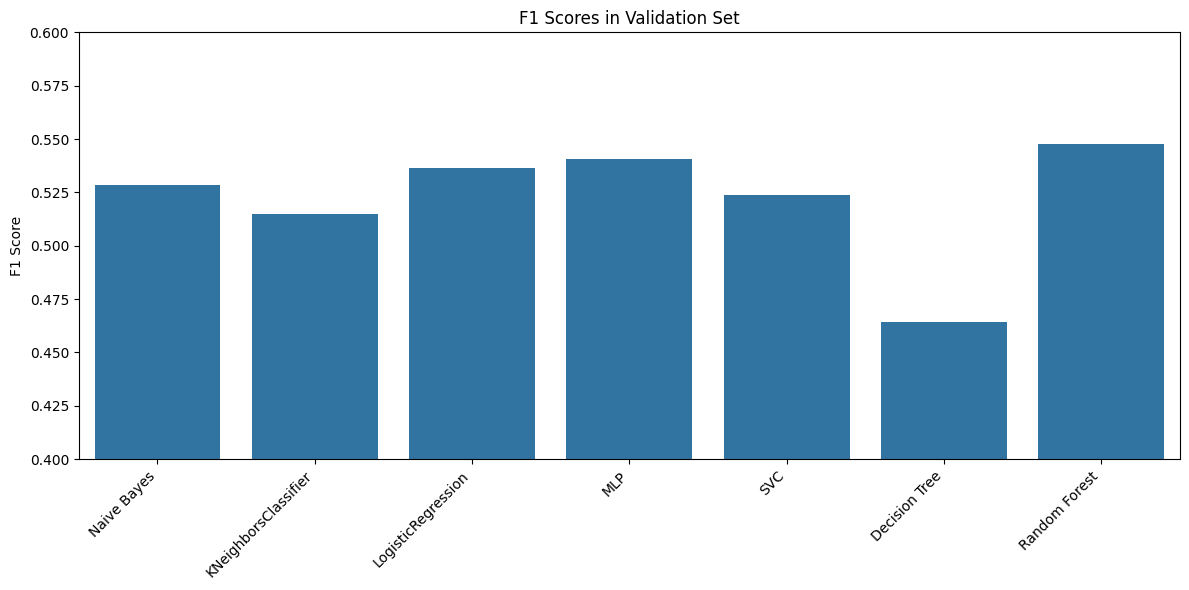

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

# All F1
f1_scores = {
    'Naive Bayes': f1_nb,
    'KNeighborsClassifier': f1_knn,
    'LogisticRegression': f1_lr,
    'MLP': f1_mlp,
    'SVC': f1_svc,
    'Decision Tree': f1_dt,
    'Random Forest': f1_rf
}

# Bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x=list(f1_scores.keys()), y=list(f1_scores.values()))
plt.ylabel('F1 Score')
plt.title('F1 Scores in Validation Set')
plt.xticks(rotation=45, ha='right')
plt.ylim(0.4, 0.6)
plt.tight_layout()
plt.show()

All models achieve an F1 score around 0.5, and this remains the case even after small preprocessing adjustments for testing. The best‑performing model appears to be the Random Forest, but even it does not exceed 0.55. What we suspect is happening is that the dataset contains far more ‘No’ than ‘Yes’ values in RainTomorrow. As a result, the algorithm learns to predict that it will not rain the next day, leading to many false negatives and therefore lowering the F1 score. To mitigate this issue, we need to tune the hyperparameters more carefully and use balanced class weights wherever possible.

In [60]:
# % yes:
yes_proportion = y.value_counts(normalize=True)['Yes']

print(f"Percentage of 'Yes' in RainTomorrow: {yes_proportion:.4f}")

Percentage of 'Yes' in RainTomorrow: 0.2364


## Cross Validation and Hyperparameter Tuning

In [61]:
from sklearn.metrics import f1_score, precision_score, recall_score, make_scorer
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
#Needed for evaluation
scoring = {
    'f1': make_scorer(f1_score, pos_label=1),
    'precision': make_scorer(precision_score, pos_label=1),
    'recall': make_scorer(recall_score, pos_label=1)
}

# Weights for y_train
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# Dictionary
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

# Weights for sampling y_train
sample_weights = np.array([class_weight_dict[label] for label in y_train])

In [62]:
#Naive Bayes
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, make_scorer
import pandas as pd

# The Model
nb_model = GaussianNB()

# Tuning
param_grid = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
}

# 5-fold validation
grid_search = GridSearchCV(
    estimator=nb_model,
    param_grid=param_grid,
    scoring=scoring,
    cv=5,
    n_jobs=-1,
    refit='f1'
)

# Train
grid_search.fit(X_train, y_train, sample_weight=sample_weights)

# Evaluation
print("Best F1 score:", grid_search.best_score_)
print("Best var_smoothing:", grid_search.best_params_['var_smoothing'])

# All F1 scores
results = pd.DataFrame(grid_search.cv_results_)
display(results[['param_var_smoothing', 'mean_test_f1', 'std_test_f1', 'mean_test_precision', 'mean_test_recall']])

Best F1 score: 0.5790917918622462
Best var_smoothing: 1e-09


,param_var_smoothing,mean_test_f1,std_test_f1,mean_test_precision,mean_test_recall
0,1.000000e-09,0.579092,0.006519,0.518564,0.65647
1,1.000000e-08,0.579092,0.006519,0.518564,0.65647
2,1.000000e-07,0.579092,0.006519,0.518564,0.65647
3,1.000000e-06,0.579092,0.006519,0.518564,0.65647
4,1.000000e-05,0.579092,0.006519,0.518564,0.65647


In [63]:
#KNeighborsClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, make_scorer
import pandas as pd

# The Model
knn = KNeighborsClassifier()

# Tuning
param_grid = {
    'n_neighbors': [3, 5, 7, 15, 30, 50],
    'weights': ['uniform', 'distance'],
    'metric': ['minkowski'],
    'p': [1, 2]
}


grid_search_knn = GridSearchCV(knn, param_grid, scoring=scoring, refit='f1', cv=5, n_jobs=-1)

# Train
grid_search_knn.fit(X_train, y_train)

# Evaluation
print("Best F1 (CV):", grid_search_knn.best_score_)
print("Best Parameters:", grid_search_knn.best_params_)

# All F1 scores
results_knn = pd.DataFrame(grid_search_knn.cv_results_)
display(results_knn[['param_n_neighbors', 'param_weights', 'param_p', 'mean_test_f1', 'std_test_f1', 'mean_test_precision', 'mean_test_recall']])

Best F1 (CV): 0.5206961994018002
Best Parameters: {'metric': 'minkowski', 'n_neighbors': 7, 'p': 2, 'weights': 'distance'}


,param_n_neighbors,param_weights,param_p,mean_test_f1,std_test_f1,mean_test_precision,mean_test_recall
0,3,uniform,1,0.507099,0.020438,0.614467,0.432341
1,3,distance,1,0.508403,0.018930,0.614395,0.434178
2,3,uniform,2,0.511680,0.013309,0.594306,0.449481
3,3,distance,2,0.513075,0.011431,0.594762,0.451318
4,5,uniform,1,0.497651,0.016303,0.646402,0.404775
5,5,distance,1,0.500283,0.016391,0.649017,0.407225
6,5,uniform,2,0.514213,0.018571,0.645908,0.427420
7,5,distance,2,0.517726,0.017907,0.648546,0.431095
8,7,uniform,1,0.488272,0.026342,0.662502,0.387013
9,7,distance,1,0.493200,0.025042,0.664445,0.392527


In [64]:
#LogisticRegression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, make_scorer
import pandas as pd

# The Model
lr = LogisticRegression(max_iter=1000)

# Tuning
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['liblinear', 'lbfgs'],
    'class_weight': [None, 'balanced']
}


# 5-fold validation
grid_search_lr = GridSearchCV(lr, param_grid, scoring=scoring, cv=5, n_jobs=-1, refit='f1')

# Train
grid_search_lr.fit(X_train, y_train, sample_weight=sample_weights)

# Evaluation
print("Best F1 (CV):", grid_search_lr.best_score_)
print("Best parameters:", grid_search_lr.best_params_)

# All F1 scores
results_lr = pd.DataFrame(grid_search_lr.cv_results_)
display(results_lr[['param_C', 'param_penalty', 'param_solver', 'param_class_weight', 'mean_test_f1', 'mean_test_precision', 'mean_test_recall', 'std_test_f1']])

Best F1 (CV): 0.5929235870443686
Best parameters: {'C': 0.001, 'class_weight': None, 'penalty': 'l2', 'solver': 'lbfgs'}


,param_C,param_penalty,param_solver,param_class_weight,mean_test_f1,mean_test_precision,mean_test_recall,std_test_f1
0,0.001,l2,liblinear,None,0.579113,0.460973,0.778935,0.012077
1,0.001,l2,lbfgs,None,0.592924,0.492913,0.744024,0.012448
2,0.001,l2,liblinear,balanced,0.494989,0.336269,0.937536,0.002381
3,0.001,l2,lbfgs,balanced,0.434742,0.279352,0.979796,0.002501
4,0.010,l2,liblinear,None,0.590313,0.486456,0.750753,0.013499
5,0.010,l2,lbfgs,None,0.592917,0.494794,0.739729,0.015215
6,0.010,l2,liblinear,balanced,0.495342,0.336688,0.936921,0.004285
7,0.010,l2,lbfgs,balanced,0.487139,0.328481,0.942431,0.004746
8,0.100,l2,liblinear,None,0.589229,0.489965,0.739121,0.012402
9,0.100,l2,lbfgs,None,0.589405,0.490759,0.737898,0.012093


In [65]:
#MLP with a hidden level
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, make_scorer

# The Model
mlp = MLPClassifier(max_iter=1000, random_state=42)

# Tuning
param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (150,)],
    'activation': ['relu','tanh'],
    'learning_rate': ['constant','adaptive']
}

# Train
grid_search_mlp = GridSearchCV(mlp, param_grid, scoring=scoring,cv=5, n_jobs=-1, refit='f1')
grid_search_mlp.fit(X_train, y_train)

# Evaluation
print("Best (CV):", grid_search_mlp.best_score_)
print("Best Parameters:", grid_search_mlp.best_params_)

# All F1 scores
results_mlp = pd.DataFrame(grid_search_mlp.cv_results_)
display(results_mlp[['param_hidden_layer_sizes', 'param_activation', 'mean_test_f1', 'std_test_f1', 'mean_test_precision', 'mean_test_recall']])

Best (CV): 0.5664149109680287
Best Parameters: {'activation': 'relu', 'hidden_layer_sizes': (100,), 'learning_rate': 'constant'}


,param_hidden_layer_sizes,param_activation,mean_test_f1,std_test_f1,mean_test_precision,mean_test_recall
0,"(50,)",relu,0.558636,0.024277,0.661481,0.483775
1,"(50,)",relu,0.558636,0.024277,0.661481,0.483775
2,"(100,)",relu,0.566415,0.010066,0.629947,0.515015
3,"(100,)",relu,0.566415,0.010066,0.629947,0.515015
4,"(150,)",relu,0.552994,0.010805,0.619758,0.500936
5,"(150,)",relu,0.552994,0.010805,0.619758,0.500936
6,"(50,)",tanh,0.536380,0.006300,0.601142,0.485606
7,"(50,)",tanh,0.536380,0.006300,0.601142,0.485606
8,"(100,)",tanh,0.516864,0.011804,0.550012,0.488057
9,"(100,)",tanh,0.516864,0.011804,0.550012,0.488057


In [66]:
#SVC
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, make_scorer
import pandas as pd

# The Model
svc = SVC(probability=True, random_state=42)

# Tuning
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf','sigmoid'],
    'gamma': ['scale', 'auto'],
    'class_weight': [None, 'balanced']
}

# 5-fold validation with multiple scorers and refit='f1'
grid_search_svc = GridSearchCV(svc, param_grid, scoring=scoring, refit='f1', cv=5, n_jobs=-1)

# Train
grid_search_svc.fit(X_train, y_train, sample_weight=sample_weights)

# Evaluation
print("Best F1 (CV):", grid_search_svc.best_score_)
print("Best parameters:", grid_search_svc.best_params_)

# All F1 scores
results_svc = pd.DataFrame(grid_search_svc.cv_results_)
display(results_svc[['param_C', 'param_kernel', 'param_gamma', 'param_class_weight', 'mean_test_f1', 'mean_test_precision', 'mean_test_recall', 'std_test_f1']])

Best F1 (CV): 0.6049260953449878
Best parameters: {'C': 1, 'class_weight': None, 'gamma': 'scale', 'kernel': 'rbf'}


,param_C,param_kernel,param_gamma,param_class_weight,mean_test_f1,mean_test_precision,mean_test_recall,std_test_f1
0,0.1,rbf,scale,None,0.601026,0.505374,0.741581,0.008024
1,0.1,sigmoid,scale,None,0.548193,0.453149,0.693812,0.012901
2,0.1,rbf,auto,None,0.601223,0.505368,0.742192,0.008081
3,0.1,sigmoid,auto,None,0.550315,0.455833,0.694426,0.012472
4,0.1,rbf,scale,balanced,0.467636,0.309362,0.957744,0.005495
5,0.1,sigmoid,scale,balanced,0.480776,0.329394,0.889777,0.007275
6,0.1,rbf,auto,balanced,0.467506,0.309252,0.957744,0.005844
7,0.1,sigmoid,auto,balanced,0.483754,0.331771,0.892831,0.007037
8,1.0,rbf,scale,None,0.604926,0.520445,0.722602,0.006777
9,1.0,sigmoid,scale,None,0.499354,0.396220,0.675434,0.012042


In [67]:
#Decision Tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, make_scorer
import pandas as pd

# The Model
dt = DecisionTreeClassifier(random_state=42)

# Tuning
param_grid = {
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy'],
    'class_weight': [None, 'balanced']
}

# 5-fold validation
grid_search_dt = GridSearchCV(dt, param_grid, scoring=scoring, refit='f1', cv=5, n_jobs=-1)

# Train with sample_weight
grid_search_dt.fit(X_train, y_train, sample_weight=sample_weights)

# Evaluation
print("Best F1:", grid_search_dt.best_score_)
print("Best Parameters:", grid_search_dt.best_params_)

# All F1 scores
results_dt = pd.DataFrame(grid_search_dt.cv_results_)
display(results_dt[['param_max_depth', 'param_min_samples_split', 'param_min_samples_leaf', 'param_criterion', 'param_class_weight', 'mean_test_f1', 'mean_test_precision', 'mean_test_recall', 'std_test_f1']])

Best F1: 0.5709154174582565
Best Parameters: {'class_weight': None, 'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}


,param_max_depth,param_min_samples_split,param_min_samples_leaf,param_criterion,param_class_weight,mean_test_f1,mean_test_precision,mean_test_recall,std_test_f1
0,None,2,1,gini,None,0.451387,0.458579,0.444594,0.008656
1,None,5,1,gini,None,0.466266,0.441396,0.494827,0.015507
2,None,10,1,gini,None,0.489022,0.436943,0.555434,0.011511
3,None,2,2,gini,None,0.477447,0.442494,0.518698,0.017113
4,None,5,2,gini,None,0.483152,0.439002,0.537684,0.020207
...,...,...,...,...,...,...,...,...,...
139,20,5,2,entropy,balanced,0.474005,0.438014,0.518105,0.017109
140,20,10,2,entropy,balanced,0.489770,0.420038,0.587910,0.021183
141,20,2,4,entropy,balanced,0.496409,0.416380,0.614821,0.015395
142,20,5,4,entropy,balanced,0.496409,0.416380,0.614821,0.015395


In [68]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, make_scorer
import pandas as pd

# The Model
rf = RandomForestClassifier(random_state=42)

# Tuning
param_grid = {
    'n_estimators': [200, 300 ,400],
    'max_depth': [None, 10],
    'min_samples_split': [ 5 , 7],
    'min_samples_leaf': [1, 2],
    'class_weight': [None, 'balanced']
}

# 5-fold validation
grid_search_rf = GridSearchCV(rf, param_grid, scoring=scoring, refit='f1', cv=5, n_jobs=-1)

# Train with sample_weight
grid_search_rf.fit(X_train, y_train, sample_weight=sample_weights)

# Evaluation
print("Best F1:", grid_search_rf.best_score_)
print("Best parameters:", grid_search_rf.best_params_)

# All F1 scores
results_rf = pd.DataFrame(grid_search_rf.cv_results_)
display(results_rf[['param_n_estimators', 'param_max_depth', 'param_min_samples_split', 'param_min_samples_leaf', 'param_class_weight', 'mean_test_f1', 'mean_test_precision', 'mean_test_recall', 'std_test_f1']])

Best F1: 0.6091840080865942
Best parameters: {'class_weight': None, 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 7, 'n_estimators': 200}


,param_n_estimators,param_max_depth,param_min_samples_split,param_min_samples_leaf,param_class_weight,mean_test_f1,mean_test_precision,mean_test_recall,std_test_f1
0,200,None,5,1,None,0.555170,0.685781,0.466659,0.020001
1,300,None,5,1,None,0.556693,0.687519,0.467881,0.019367
2,400,None,5,1,None,0.558887,0.687704,0.470942,0.021537
3,200,None,7,1,None,0.573098,0.667709,0.502163,0.013217
4,300,None,7,1,None,0.579388,0.670683,0.510126,0.013100
5,400,None,7,1,None,0.577381,0.669526,0.507679,0.013484
6,200,None,5,2,None,0.573072,0.663599,0.504619,0.013143
7,300,None,5,2,None,0.578182,0.669759,0.508900,0.009386
8,400,None,5,2,None,0.576630,0.666616,0.508293,0.014414
9,200,None,7,2,None,0.589068,0.652737,0.537067,0.007208


In [69]:
#Naive Bayes
# Keeping the best model and predicting
best_nb = grid_search.best_estimator_
y_pred_nb = best_nb.predict(X_val)

In [70]:
#KNeighborsClassifier
# Keeping the best model and predicting
best_knn = grid_search_knn.best_estimator_
y_pred_knn = best_knn.predict(X_val)

In [71]:
#LogisticRegression
# Keeping the best model and predicting
best_lr = grid_search_lr.best_estimator_
y_pred_val_lr = best_lr.predict(X_val)

In [72]:
# MLP με κρυφό επίπεδο
# Keeping the best model and predicting
best_mlp = grid_search_mlp.best_estimator_
y_pred_val_mlp = best_mlp.predict(X_val)

In [73]:
# SVC
# Keeping the best model and predicting
best_svc = grid_search_svc.best_estimator_
y_pred_val_svc = best_svc.predict(X_val)

In [74]:
# Decision Tree
# Keeping the best model and predicting
best_dt = grid_search_dt.best_estimator_
y_pred_val_dt = best_dt.predict(X_val)

In [75]:
# Random Forest
# Keeping the best model and predicting
best_rf = grid_search_rf.best_estimator_
y_pred_val_rf = best_rf.predict(X_val)

Evaluating validation

In [76]:
#Naive Bayes
f1_val_nb = f1_score(y_val, y_pred_nb, pos_label=1)
print("F1 score in validation:", f1_val_nb)

F1 score in validation: 0.5754119138149556


In [77]:
#KNeighborsClassifier
f1_val_knn = f1_score(y_val, y_pred_knn, pos_label=1)
print("F1 score in validation:", f1_knn)

F1 score in validation: 0.5150214592274678


In [78]:
#LogisticRegression
f1_val_lr = f1_score(y_val, y_pred_val_lr, pos_label=1)
print("Logistic Regression F1 score in validation:", f1_val_lr)

Logistic Regression F1 score in validation: 0.5922107674684994


In [79]:
# MLP με ένα κρυφό επίπεδο
f1_val_mlp = f1_score(y_val, y_pred_val_mlp, pos_label=1)
print("MLP F1 score in validation:", f1_val_mlp)

MLP F1 score in validation: 0.5405831363278172


In [80]:
#SVC
f1_val_svc = f1_score(y_val, y_pred_val_svc, pos_label=1)
print("SVC F1 score in validation:", f1_val_svc)

SVC F1 score in validation: 0.6013150029886432


In [81]:
# Decision Tree
f1_val_dt = f1_score(y_val, y_pred_val_dt, pos_label=1)
print("Decision Tree F1 score in validation:", f1_val_dt)

Decision Tree F1 score in validation: 0.5775


In [82]:
# Random Forest
f1_val_rf = f1_score(y_val, y_pred_val_rf, pos_label=1)
print("Random Forest F1 score in validation:", f1_val_rf)

Random Forest F1 score in validation: 0.6029515108924807


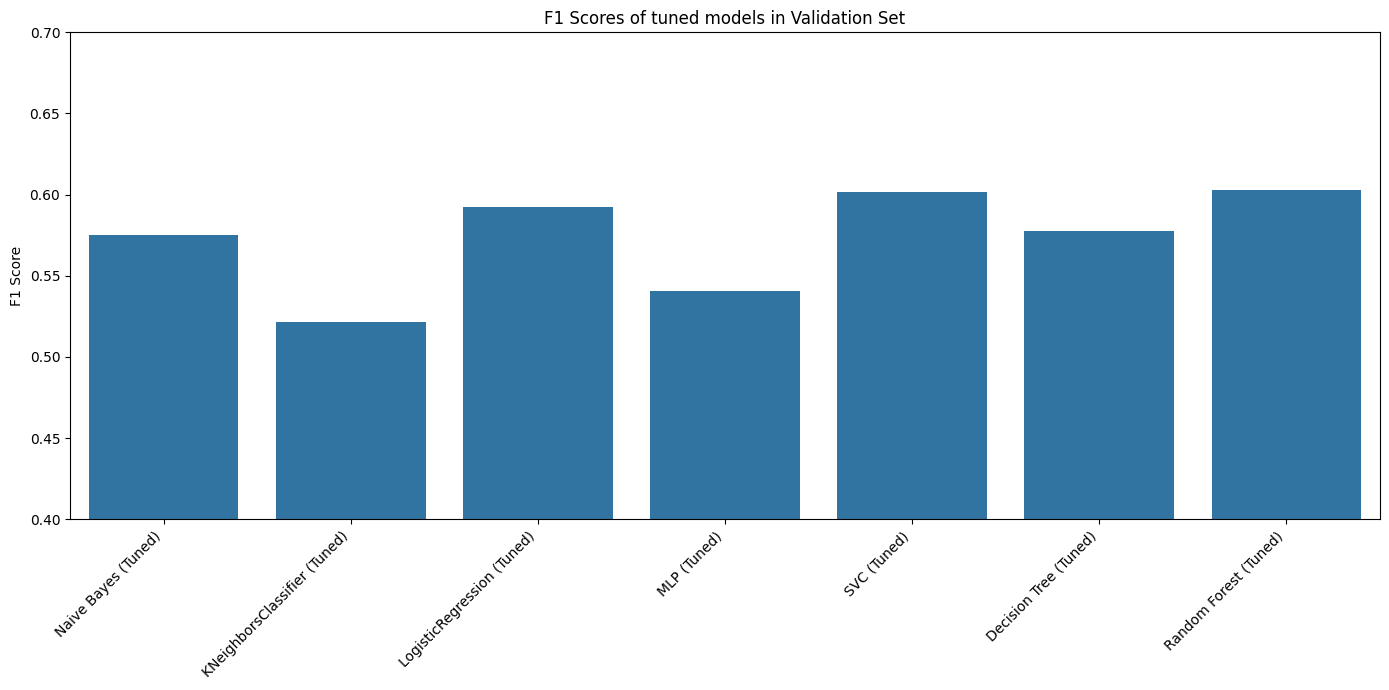

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns

# Dictionary of F1 values
f1_scores_tuned = {
    'Naive Bayes (Tuned)': f1_val_nb,
    'KNeighborsClassifier (Tuned)': f1_val_knn,
    'LogisticRegression (Tuned)': f1_val_lr,
    'MLP (Tuned)': f1_val_mlp,
    'SVC (Tuned)': f1_val_svc,
    'Decision Tree (Tuned)': f1_val_dt,
    'Random Forest (Tuned)': f1_val_rf
}

# Bar plot
plt.figure(figsize=(14, 7))
sns.barplot(x=list(f1_scores_tuned.keys()), y=list(f1_scores_tuned.values()))
plt.ylabel('F1 Score')
plt.title('F1 Scores of tuned models in Validation Set')
plt.xticks(rotation=45, ha='right')
plt.ylim(0.4, 0.7)
plt.tight_layout()
plt.show()

After identifying more suitable hyperparameters, the models appear to perform slightly better, as the F1 scores have increased. The best‑performing model is the Random Forest, achieving an F1 score of 0.603.

## Testing tuned models


In [84]:
from google.colab import files
uploaded = files.upload()

Saving test.csv to test.csv


In [85]:
test_df = pd.read_csv('test.csv')
# We repeat the process
test_df.dropna(subset=['RainTomorrow'], inplace=True)

# preprocess
# Imputing
test_df['Evaporation'] = test_df.groupby('Location')['Evaporation'].transform(lambda x: x.fillna(x.mean()))

# Location droping
test_df = test_df.drop('Location', axis=1)

# Date
test_df['Date'] = pd.to_datetime(test_df['Date'])
test_df['Year'] = test_df['Date'].dt.year
test_df['Month'] = test_df['Date'].dt.month
test_df['Day'] = test_df['Date'].dt.day
test_df = test_df.drop(columns=['Date'])


# Directions
direction_map = {
    'N': 0, 'NNE': 22.5, 'NE': 45, 'ENE': 67.5, 'E': 90, 'ESE': 112.5,
    'SE': 135, 'SSE': 157.5, 'S': 180, 'SSW': 202.5, 'SW': 225, 'WSW': 247.5,
    'W': 270, 'WNW': 292.5, 'NW': 315, 'NNW': 337.5
}
wind_direction_cols = ['WindGustDir', 'WindDir9am', 'WindDir3pm']
for col in wind_direction_cols:
    test_df[col] = test_df[col].map(direction_map)

# Mean
test_df['MeanWindDir'] = test_df[['WindDir9am', 'WindDir3pm']].mean(axis=1)
valid_angles = np.array(list(direction_map.values()))
test_df['MeanWindDir'] = test_df['MeanWindDir'].apply(lambda x: valid_angles[np.argmin(np.abs(valid_angles - x))] if pd.notna(x) else x)

# mean temperature, wind, humidity, και cloud
test_df['MeanTemp'] = test_df[['MaxTemp', 'MinTemp']].mean(axis=1)
test_df['MeanWind'] = test_df[['WindSpeed9am', 'WindSpeed3pm']].mean(axis=1)
test_df['MeanHumidity'] = test_df[['Humidity9am', 'Humidity3pm']].mean(axis=1)
test_df['MeanCloud'] = test_df[['Cloud9am', 'Cloud3pm']].mean(axis=1)

# Keep
columns_to_keep = ['Rainfall', 'Evaporation', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'Pressure3pm', 'MeanTemp', 'MeanWind', 'MeanHumidity', 'MeanCloud', 'MeanWindDir', 'Year', 'Month','RainTomorrow']
test_df = test_df[columns_to_keep]

# Split X and Y
X_test = test_df.iloc[:, :-1]
y_test = test_df.iloc[:, -1]
y_test_processed = y_test.map({'No': 0, 'Yes': 1})


# we call the same preprocessor transformer from training
X_test_processed = preprocessor.transform(X_test)


print("X_test_processed shape:", X_test_processed.shape)
print("y_test_processed shape:", y_test_processed.shape)

/tmp/ipykernel_22598/2057268333.py:13: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  test_df['Date'] = pd.to_datetime(test_df['Date'])


X_test_processed shape: (4468, 11)
y_test_processed shape: (4468,)


In [86]:
# Predict all models
y_pred_test_nb = best_nb.predict(X_test_processed)
y_pred_test_knn = best_knn.predict(X_test_processed)
y_pred_test_lr = best_lr.predict(X_test_processed)
y_pred_test_mlp = best_mlp.predict(X_test_processed)
y_pred_test_svc = best_svc.predict(X_test_processed)
y_pred_test_dt = best_dt.predict(X_test_processed)
y_pred_test_rf = best_rf.predict(X_test_processed)

In [87]:
from sklearn.metrics import f1_score, precision_score, recall_score

# Test every model
f1_test_nb = f1_score(y_test_processed, y_pred_test_nb)
precision_test_nb = precision_score(y_test_processed, y_pred_test_nb)
recall_test_nb = recall_score(y_test_processed, y_pred_test_nb)

f1_test_knn = f1_score(y_test_processed, y_pred_test_knn)
precision_test_knn = precision_score(y_test_processed, y_pred_test_knn)
recall_test_knn = recall_score(y_test_processed, y_pred_test_knn)

f1_test_lr = f1_score(y_test_processed, y_pred_test_lr)
precision_test_lr = precision_score(y_test_processed, y_pred_test_lr)
recall_test_lr = recall_score(y_test_processed, y_pred_test_lr)

f1_test_mlp = f1_score(y_test_processed, y_pred_test_mlp)
precision_test_mlp = precision_score(y_test_processed, y_pred_test_mlp)
recall_test_mlp = recall_score(y_test_processed, y_pred_test_mlp)

f1_test_svc = f1_score(y_test_processed, y_pred_test_svc)
precision_test_svc = precision_score(y_test_processed, y_pred_test_svc)
recall_test_svc = recall_score(y_test_processed, y_pred_test_svc)

f1_test_dt = f1_score(y_test_processed, y_pred_test_dt)
precision_test_dt = precision_score(y_test_processed, y_pred_test_dt)
recall_test_dt = recall_score(y_test_processed, y_pred_test_dt)

f1_test_rf = f1_score(y_test_processed, y_pred_test_rf)
precision_test_rf = precision_score(y_test_processed, y_pred_test_rf)
recall_test_rf = recall_score(y_test_processed, y_pred_test_rf)

# Evaluation
print("Naive Bayes:")
print(f"  F1 Score: {f1_test_nb:.4f}")
print(f"  Precision: {precision_test_nb:.4f}")
print(f"  Recall: {recall_test_nb:.4f}")
print("\nKNeighborsClassifier:")
print(f"  F1 Score: {f1_test_knn:.4f}")
print(f"  Precision: {precision_test_knn:.4f}")
print(f"  Recall: {recall_test_knn:.4f}")
print("\nLogisticRegression:")
print(f"  F1 Score: {f1_test_lr:.4f}")
print(f"  Precision: {precision_test_lr:.4f}")
print(f"  Recall: {recall_test_lr:.4f}")
print("\nMLP:")
print(f"  F1 Score: {f1_test_mlp:.4f}")
print(f"  Precision: {precision_test_mlp:.4f}")
print(f"  Recall: {recall_test_mlp:.4f}")
print("\nSVC:")
print(f"  F1 Score: {f1_test_svc:.4f}")
print(f"  Precision: {precision_test_svc:.4f}")
print(f"  Recall: {recall_test_svc:.4f}")
print("\nDecision Tree:")
print(f"  F1 Score: {f1_test_dt:.4f}")
print(f"  Precision: {precision_test_dt:.4f}")
print(f"  Recall: {recall_test_dt:.4f}")
print("\nRandom Forest:")
print(f"  F1 Score: {f1_test_rf:.4f}")
print(f"  Precision: {precision_test_rf:.4f}")
print(f"  Recall: {recall_test_rf:.4f}")

Naive Bayes:
  F1 Score: 0.5821
  Precision: 0.5077
  Recall: 0.6820

KNeighborsClassifier:
  F1 Score: 0.5243
  Precision: 0.6591
  Recall: 0.4353

LogisticRegression:
  F1 Score: 0.5961
  Precision: 0.4912
  Recall: 0.7580

MLP:
  F1 Score: 0.5915
  Precision: 0.6480
  Recall: 0.5441

SVC:
  F1 Score: 0.6262
  Precision: 0.5329
  Recall: 0.7589

Decision Tree:
  F1 Score: 0.5852
  Precision: 0.5072
  Recall: 0.6914

Random Forest:
  F1 Score: 0.6202
  Precision: 0.6068
  Recall: 0.6341


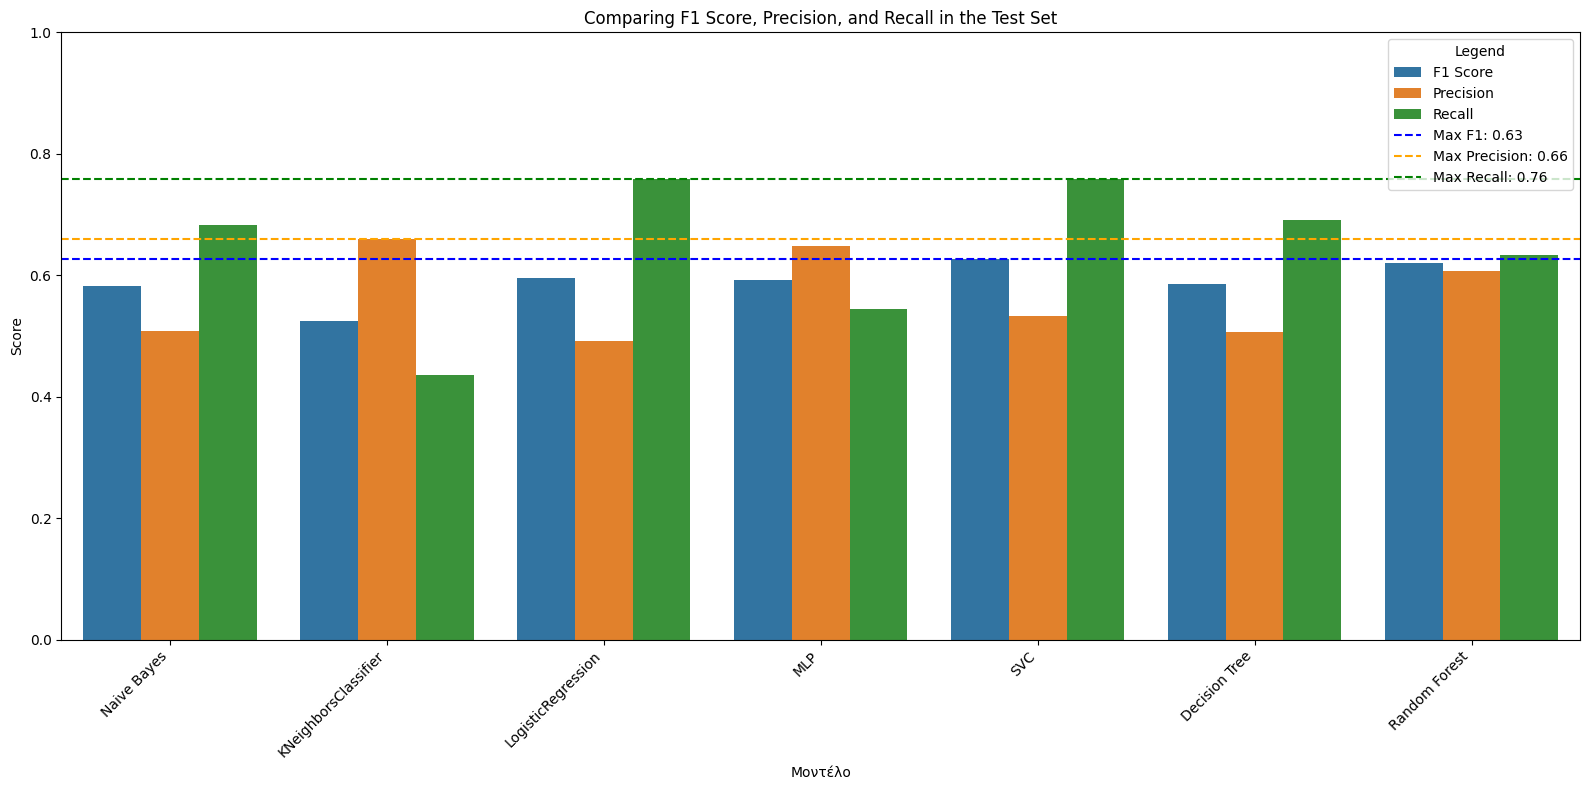

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# All evaluation metrics
test_metrics = {
    'Model': ['Naive Bayes', 'KNeighborsClassifier', 'LogisticRegression', 'MLP', 'SVC', 'Decision Tree', 'Random Forest'],
    'F1 Score': [f1_test_nb, f1_test_knn, f1_test_lr, f1_test_mlp, f1_test_svc, f1_test_dt, f1_test_rf],
    'Precision': [precision_test_nb, precision_test_knn, precision_test_lr, precision_test_mlp, precision_test_svc, precision_test_dt, precision_test_rf],
    'Recall': [recall_test_nb, recall_test_knn, recall_test_lr, recall_test_mlp, recall_test_svc, recall_test_dt, recall_test_rf]
}

# Ploting transformations
test_metrics_df = pd.DataFrame(test_metrics)
test_metrics_melted = test_metrics_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

# Bar plot
plt.figure(figsize=(16, 8))
sns.barplot(x='Model', y='Score', hue='Metric', data=test_metrics_melted)
plt.ylabel('Score')
plt.xlabel('Μοντέλο')
plt.title('Comparing F1 Score, Precision, and Recall in the Test Set')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)

# Lines for comparisons
plt.axhline(y=test_metrics_df['F1 Score'].max(), color='blue', linestyle='--', label=f'Max F1: {test_metrics_df["F1 Score"].max():.2f}')
plt.axhline(y=test_metrics_df['Precision'].max(), color='orange', linestyle='--', label=f'Max Precision: {test_metrics_df["Precision"].max():.2f}')
plt.axhline(y=test_metrics_df['Recall'].max(), color='green', linestyle='--', label=f'Max Recall: {test_metrics_df["Recall"].max():.2f}')

plt.legend(title='Legend')
plt.tight_layout()
plt.show()

The best F1 score is achieved by the SVC, with a noticeable margin, followed by the Random Forest. The SVC also has the highest recall, meaning it made the fewest mistakes among all models. All models initially had very low recall, which I realized was due to the strong class imbalance in the dataset: the vast majority of RainTomorrow values in the original training set are ‘No’ (~80%). As a result, the algorithms tended to predict that it would not rain, leading to many false negatives.

To address this issue, I introduced class_weight='balanced' in all models that support it (SVC, Logistic Regression, Decision Tree, Random Forest). With this adjustment, the recall of the models increases significantly, making the SVC the best-performing model overall, with an F1 score of 0.63.

The best balance is observed in the Random Forest model. Like all methods, it initially showed a large discrepancy between precision and recall, but after introducing balanced class weights, the balance between the two becomes impressive—though expected. Since the model consists of many smaller trees that may overfit or miss the target individually, the ensemble is able to average their predictions in a way that does not lean excessively toward precision or recall.

### Per fold performance

In [89]:
model_names = [
    'Naive Bayes',
    'KNeighborsClassifier',
    'Logistic Regression',
    'MLP',
    'SVC',
    'Decision Tree',
    'Random Forest'
]

grid_search_objects = [
    grid_search,
    grid_search_knn,
    grid_search_lr,
    grid_search_mlp,
    grid_search_svc,
    grid_search_dt,
    grid_search_rf
]

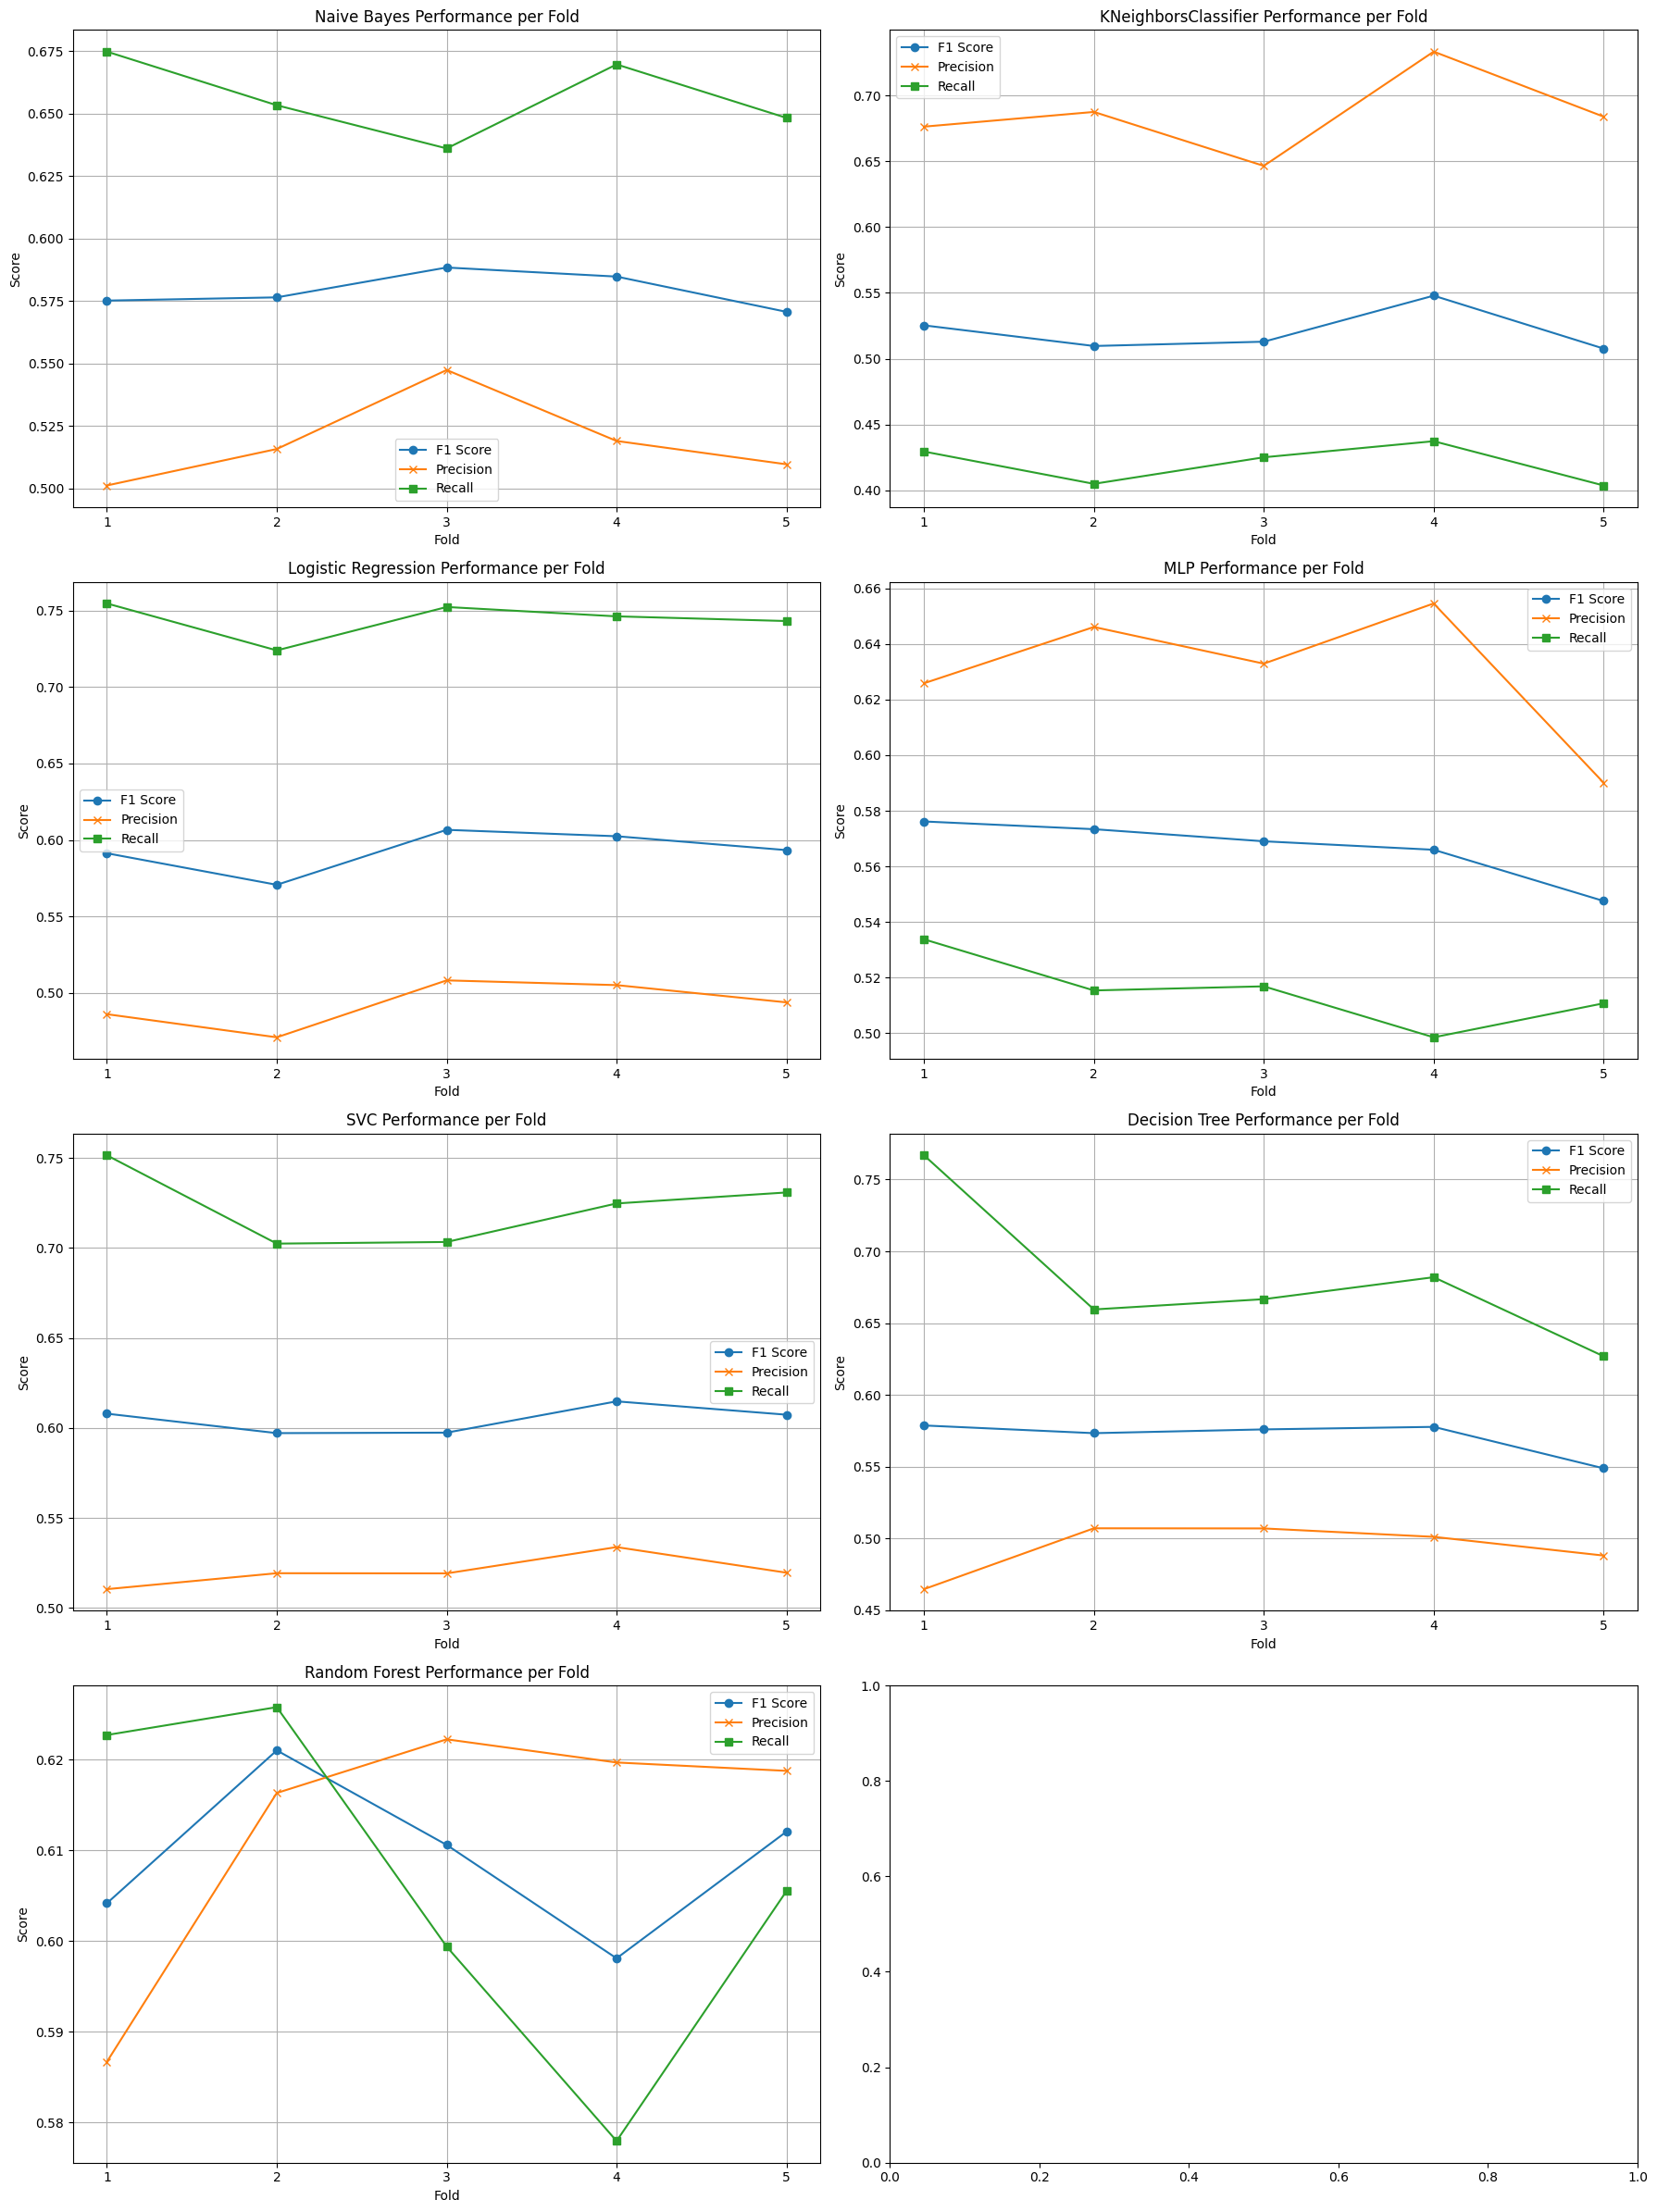

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Plot each model
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(18, 24))
axes = axes.flatten()

for i, (model_name, grid_search_obj) in enumerate(zip(model_names, grid_search_objects)):
    if i < len(axes):
        best_index = grid_search_obj.best_index_

        # F1, precision, and recall scores
        f1_scores = [grid_search_obj.cv_results_[f'split{j}_test_f1'][best_index] for j in range(5)]
        precision_scores = [grid_search_obj.cv_results_[f'split{j}_test_precision'][best_index] for j in range(5)]
        recall_scores = [grid_search_obj.cv_results_[f'split{j}_test_recall'][best_index] for j in range(5)]

        folds = np.arange(1, 6)

        # Per model and fold plots.
        axes[i].plot(folds, f1_scores, marker='o', label='F1 Score')
        axes[i].plot(folds, precision_scores, marker='x', label='Precision')
        axes[i].plot(folds, recall_scores, marker='s', label='Recall')

        axes[i].set_title(f'{model_name} Performance per Fold')
        axes[i].set_xlabel('Fold')
        axes[i].set_ylabel('Score')
        axes[i].set_xticks(folds)
        axes[i].legend()
        axes[i].grid(True)
plt.tight_layout()
plt.show()

Deviation for folds:


,F1,Precision,Recall
Model,,,
Decision Tree,0.012496,0.017913,0.052359
KNeighborsClassifier,0.016679,0.031220,0.015075
Logistic Regression,0.013917,0.015085,0.012141
MLP,0.011255,0.024920,0.012712
Naive Bayes,0.007289,0.017475,0.015850
Random Forest,0.008631,0.014703,0.019353
SVC,0.007577,0.008400,0.020533



Best models in relation to deviation:
  F1: KNeighborsClassifier (Std Dev: 0.0167)
  Precision: KNeighborsClassifier (Std Dev: 0.0312)
  Recall: Decision Tree (Std Dev: 0.0524)


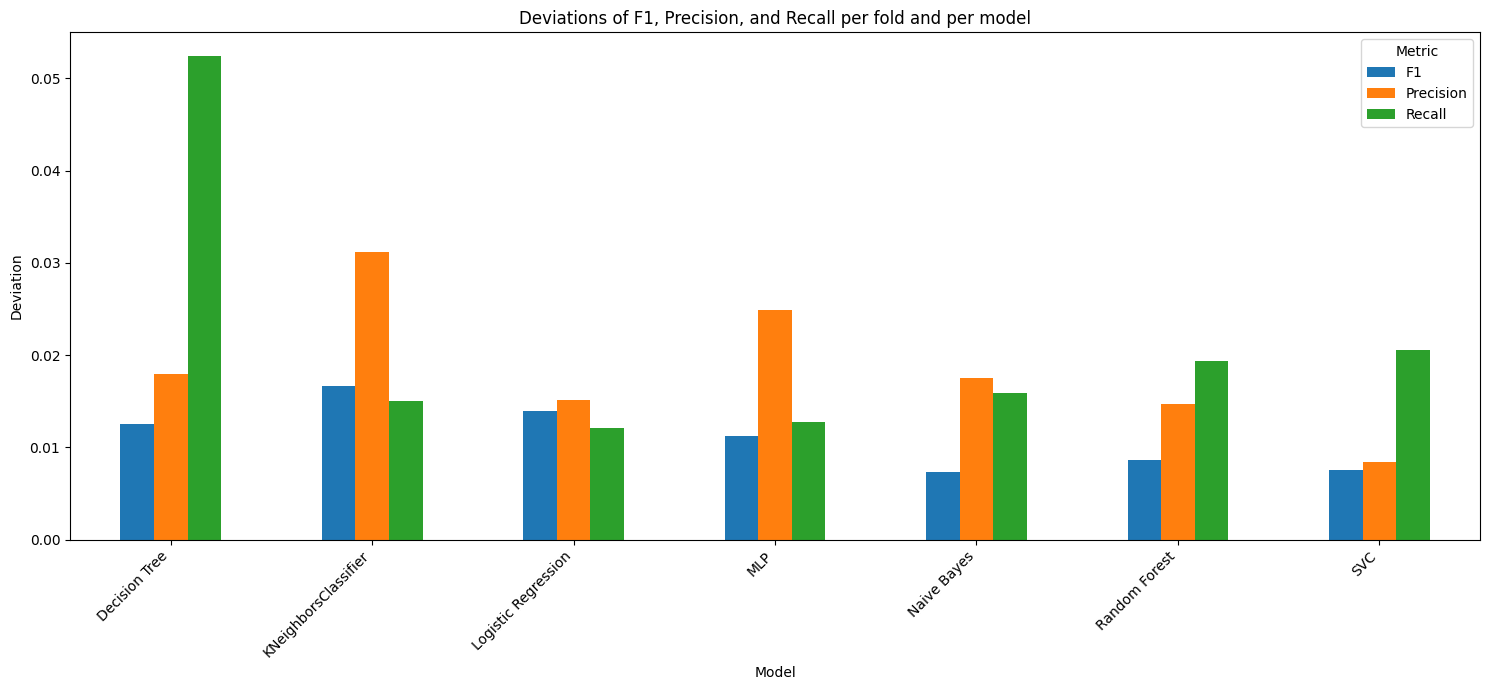

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

model_names = [
    'Naive Bayes',
    'KNeighborsClassifier',
    'Logistic Regression',
    'MLP',
    'SVC',
    'Decision Tree',
    'Random Forest'
]

grid_search_objects = [
    grid_search,
    grid_search_knn,
    grid_search_lr,
    grid_search_mlp,
    grid_search_svc,
    grid_search_dt,
    grid_search_rf
]

#Score extracting of every fold for the best fits
def extract_multi_metric_fold_metrics(grid_search_obj, model_name):
    results = pd.DataFrame(grid_search_obj.cv_results_)
    best_params_idx = grid_search_obj.best_index_

    f1_scores = [results.loc[best_params_idx, f'split{i}_test_f1'] for i in range(grid_search_obj.cv)]
    precision_scores = [results.loc[best_params_idx, f'split{i}_test_precision'] for i in range(grid_search_obj.cv)]
    recall_scores = [results.loc[best_params_idx, f'split{i}_test_recall'] for i in range(grid_search_obj.cv)]

    metrics_df = pd.DataFrame({
        'Fold': [f'Fold {i+1}' for i in range(grid_search_obj.cv)],
        'F1': f1_scores,
        'Precision': precision_scores,
        'Recall': recall_scores
    })
    metrics_df['Model'] = model_name
    return metrics_df

all_models_metrics_df = pd.DataFrame()
for model_name, grid_search_obj in zip(model_names, grid_search_objects):
    model_metrics_df = extract_multi_metric_fold_metrics(grid_search_obj, model_name)
    all_models_metrics_df = pd.concat([all_models_metrics_df, model_metrics_df], ignore_index=True)

# deviation for every model
std_dev_scores = all_models_metrics_df.groupby('Model')[['F1', 'Precision', 'Recall']].std()

print("Deviation for folds:")
display(std_dev_scores)

# Best models in relation to deviation
print("\nBest models in relation to deviation:")
for metric in std_dev_scores.columns:
    highest_std_model = std_dev_scores[metric].idxmax()
    max_std_value = std_dev_scores[metric].max()
    print(f"  {metric}: {highest_std_model} (Std Dev: {max_std_value:.4f})")

# Visualization
plt.figure(figsize=(15, 7))
std_dev_scores.plot(kind='bar', ax=plt.gca())
plt.title('Deviations of F1, Precision, and Recall per fold and per model')
plt.xlabel('Model')
plt.ylabel('Deviation')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

The largest variance is observed in the Decision Tree and the KNeighborsClassifier. The Decision Tree is more unstable because it is highly sensitive to the data, so it is expected to show such strong differences from fold to fold. Similarly, KNeighbors is also very sensitive to the data, and this effect is amplified by the strong class imbalance. Finally, due to the large number of missing values in some columns, the extensive use of imputed data may also contribute to the high variance

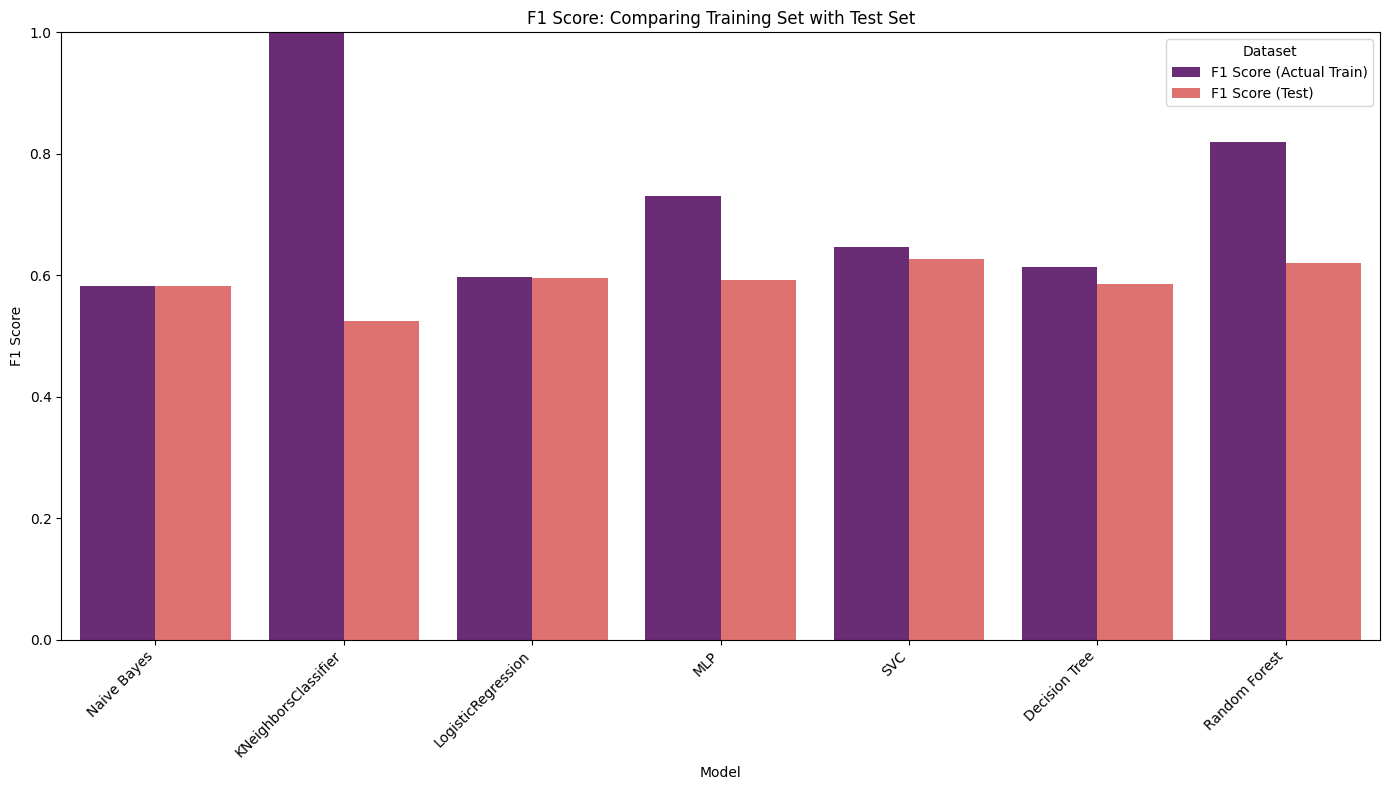

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import f1_score

# Best fit for every model
best_estimators = {
    'Naive Bayes': grid_search.best_estimator_,
    'KNeighborsClassifier': grid_search_knn.best_estimator_,
    'LogisticRegression': grid_search_lr.best_estimator_,
    'MLP': grid_search_mlp.best_estimator_,
    'SVC': grid_search_svc.best_estimator_,
    'Decision Tree': grid_search_dt.best_estimator_,
    'Random Forest': grid_search_rf.best_estimator_
}

# F1 for train
f1_train_actual = {}
for model_name, estimator in best_estimators.items():
    y_pred_train = estimator.predict(X_train)
    f1_train_actual[model_name] = f1_score(y_train, y_pred_train, pos_label=1)


f1_test_scores = {
    'Naive Bayes': f1_test_nb,
    'KNeighborsClassifier': f1_test_knn,
    'LogisticRegression': f1_test_lr,
    'MLP': f1_test_mlp,
    'SVC': f1_test_svc,
    'Decision Tree': f1_test_dt,
    'Random Forest': f1_test_rf
}

# Data frame
comparison_df = pd.DataFrame({
    'Model': list(f1_train_actual.keys()),
    'F1 Score (Actual Train)': list(f1_train_actual.values()),
    'F1 Score (Test)': list(f1_test_scores.values())
})

#
comparison_melted = comparison_df.melt(id_vars='Model', var_name='Set', value_name='F1 Score')

# Visualization
plt.figure(figsize=(14, 8))
sns.barplot(x='Model', y='F1 Score', hue='Set', data=comparison_melted, palette='magma')
plt.title('F1 Score: Comparing Training Set with Test Set')
plt.xlabel('Model')
plt.ylabel('F1 Score')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Dataset')
plt.tight_layout()
plt.show()

We can see that the KNeighborsClassifier, the MLP, and the Random Forest models exhibit overfitting on the training data. This is expected for KNeighbors, since it essentially memorizes the training set.

To improve model performance, we could either use more data—which is not possible in the current setting—or tune the hyperparameters more effectively, which is what we do through validation.

For our best model we are going to show more detailed results on false negatives positives, true negatives and positives

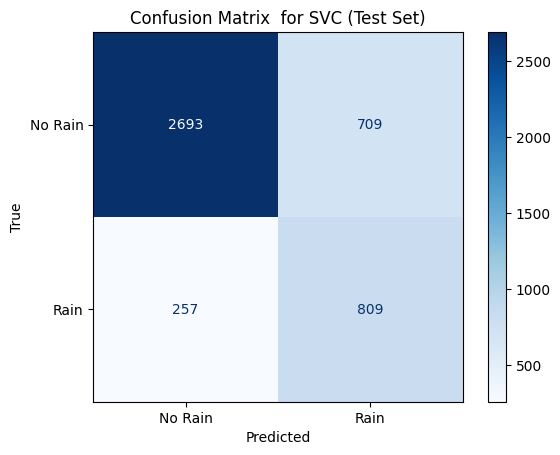

True Negatives (Predicted No, Actual No): 2693
False Positives (Predicted Yes, Actual No): 709
False Negatives (Predicted No, Actual Yes): 257
True Positives (Predicted Yes, Actual Yes): 809

--- Error Analysis ---
Total Errors: 966
(False Positives): 709
(False Negatives): 257

 Mostly False Positives.


In [93]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


# predict
y_pred_svc_test = best_svc.predict(X_test_processed)

# confusion matrix
cm = confusion_matrix(y_test_processed, y_pred_svc_test, labels=[0, 1])

# Visualization
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Rain', 'Rain'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix  for SVC (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# The important values
tn, fp, fn, tp = cm.ravel()

print(f"True Negatives (Predicted No, Actual No): {tn}")
print(f"False Positives (Predicted Yes, Actual No): {fp}")
print(f"False Negatives (Predicted No, Actual Yes): {fn}")
print(f"True Positives (Predicted Yes, Actual Yes): {tp}")


print("\n--- Error Analysis ---")

total_errors = fp + fn
print(f"Total Errors: {total_errors}")

# False Positives
errors_class_0 = fp
print(f"(False Positives): {errors_class_0}")

# False Negatives
errors_class_1 = fn
print(f"(False Negatives): {errors_class_1}")

# Which category has the most errors
if errors_class_1 > errors_class_0:
    print(f"\n Mostly False Negatives.")
elif errors_class_0 > errors_class_1:
    print(f"\n Mostly False Positives.")
else:
    print(f"\n Equal nnumber of False Negatives and False Positivies.")

The main reason we observe such a large number of false negatives is again the imbalance between the two label classes. Even after introducing balanced class weights, our best model still tends to classify samples as No Rain, simply because that class appears far more frequently in the dataset.